# LAB 05: HOG-Based Industrial Defect Detection (NEU-DET)
ATIF ALI SHAH (FA23-BAI-004)

In [2]:
# CELL 1: Dataset download (auto + manual fallback)
!pip -q install kagglehub
import kagglehub, os, zipfile

slugs = [
    "sovitrath/neu-steel-surface-defect-detect-train-valid-split",
    "sovitrath/neu-steel-surface-defect-detecttrainvalid-split",
    "kaustubhdikshit/neu-surface-defect-database",
    "fantacher/neu-metal-surface-defects-data",
]

path = None
for s in slugs:
    try:
        path = kagglehub.dataset_download(s)
        print("OK:", s)
        break
    except Exception as e:
        print("Failed:", s, "->", type(e).__name__)

if path is None:
    from google.colab import files
    print("\nAuto download fail hua. Kaggle se dataset ka ZIP download karke yahan upload karein:")
    up = files.upload()
    os.makedirs("/content/neu", exist_ok=True)
    for name in up:
        if name.endswith(".zip"):
            zipfile.ZipFile(name).extractall("/content/neu")
    path = "/content/neu"

print("Dataset path:", path)

Failed: sovitrath/neu-steel-surface-defect-detect-train-valid-split -> KaggleApiHTTPError
Failed: sovitrath/neu-steel-surface-defect-detecttrainvalid-split -> KaggleApiHTTPError
Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
OK: kaustubhdikshit/neu-surface-defect-database
Dataset path: /kaggle/input/neu-surface-defect-database


Total images: 1800 | shape: (1800, 128, 128)
crazing            300
inclusion          300
patches            300
pitted_surface     300
rolled-in_scale    300
scratches          300
Name: count, dtype: int64
Binary counts (0=normal proxy, 1=defective): [ 300 1500]


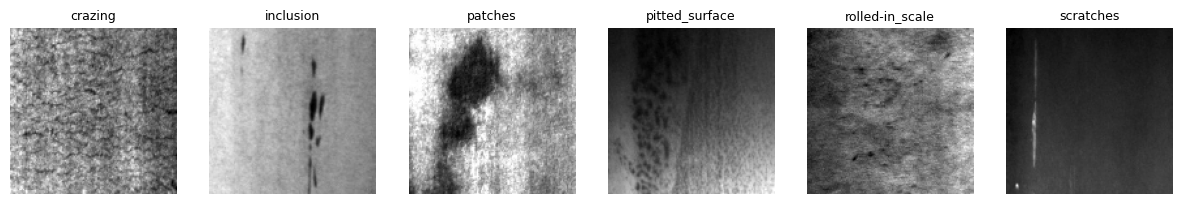

In [3]:
# CELL 2: Load + inspect + resize + grayscale
import os, re, glob, time, cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from joblib import Parallel, delayed
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

IMG_SIZE = 128
CLASSES = ['crazing','inclusion','patches','pitted_surface','rolled-in_scale','scratches']
# NEU-DET me "normal" class nahi hoti -> binary ke liye ek class ko proxy "Non-Defective" lete hain
NORMAL_CLASS = 'crazing'   # report ki Limitations me ye zaroor likhein

def get_label(f):
    m = re.match(r'^(.*?)_\d+$', os.path.splitext(os.path.basename(f))[0])
    return m.group(1) if m else None

exts = ('.jpg','.jpeg','.png','.bmp')
files, seen = [], set()
for f in sorted(glob.glob(path + '/**/*', recursive=True)):
    b = os.path.basename(f)
    if f.lower().endswith(exts) and get_label(f) in CLASSES and b not in seen:
        seen.add(b); files.append(f)

def load(f):
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)          # grayscale
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))        # common resolution

X_raw = np.array(Parallel(n_jobs=-1, prefer="threads")(delayed(load)(f) for f in files))
labels = [get_label(f) for f in files]
y_multi = np.array([CLASSES.index(l) for l in labels])
y_bin = np.array([0 if l == NORMAL_CLASS else 1 for l in labels])  # 0=Non-Defective, 1=Defective

print("Total images:", len(files), "| shape:", X_raw.shape)
print(pd.Series(labels).value_counts())
print("Binary counts (0=normal proxy, 1=defective):", np.bincount(y_bin))

fig, ax = plt.subplots(1, 6, figsize=(15, 3))
for i, c in enumerate(CLASSES):
    ax[i].imshow(X_raw[y_multi == i][0], cmap='gray'); ax[i].set_title(c, fontsize=9); ax[i].axis('off')
plt.show()

idx = np.arange(len(X_raw))
tr, te = train_test_split(idx, test_size=0.2, stratify=y_multi, random_state=42)

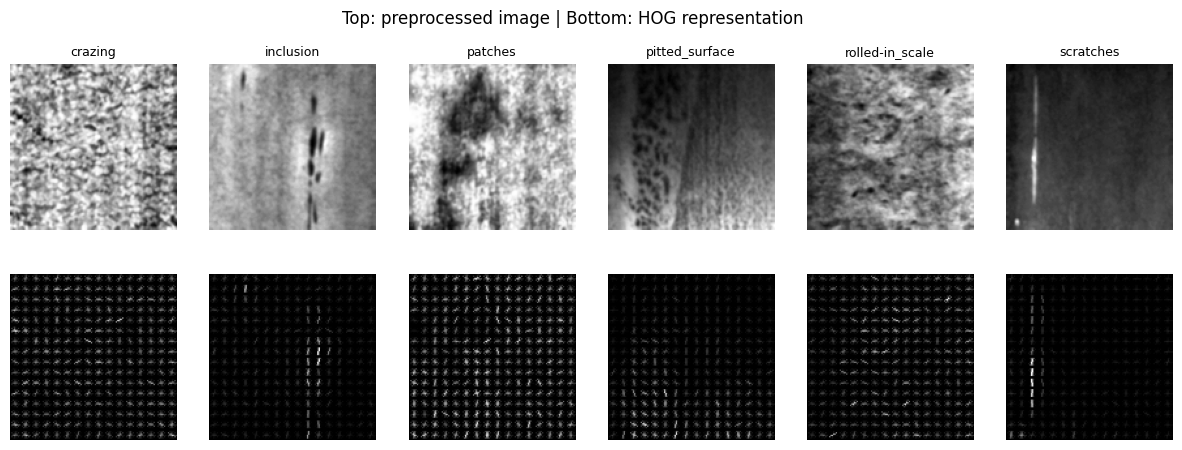

In [4]:
# CELL 3: Preprocessing + HOG function + HOG visualization
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
def preprocess(img):
    return clahe.apply(cv2.GaussianBlur(img, (3, 3), 0))

def hog_one(img, cell, ori):
    return hog(preprocess(img), orientations=ori, pixels_per_cell=(cell, cell),
               cells_per_block=(2, 2), block_norm='L2-Hys').astype(np.float32)

def extract(imgs, cell=8, ori=9):
    return np.array(Parallel(n_jobs=-1)(delayed(hog_one)(im, cell, ori) for im in imgs))

fig, ax = plt.subplots(2, 6, figsize=(15, 5))
for i, c in enumerate(CLASSES):
    im = preprocess(X_raw[y_multi == i][0])
    _, vis = hog(im, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    ax[0, i].imshow(im, cmap='gray'); ax[0, i].set_title(c, fontsize=9); ax[0, i].axis('off')
    ax[1, i].imshow(vis, cmap='gray'); ax[1, i].axis('off')
plt.suptitle("Top: preprocessed image | Bottom: HOG representation"); plt.show()

In [7]:
# CELL 4: HOG parameter study (cell size x orientations) - Binary task
def metrics(yt, yp, avg='binary'):
    return dict(Acc=accuracy_score(yt, yp),
                Prec=precision_score(yt, yp, average=avg, zero_division=0),
                Rec=recall_score(yt, yp, average=avg, zero_division=0),
                F1=f1_score(yt, yp, average=avg, zero_division=0))

rows = []
for cell in [4, 8, 16]:
    for ori in [6, 9, 12]:
        t0 = time.time()
        F = extract(X_raw, cell, ori)
        svm = LinearSVC(C=1, class_weight='balanced', max_iter=3000).fit(F[tr], y_bin[tr])
        rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42).fit(F[tr], y_bin[tr])
        for name, m in [('SVM', svm), ('RandomForest', rf)]:
            r = metrics(y_bin[te], m.predict(F[te])); r.update(Cell=f"{cell}x{cell}", Ori=ori, Model=name, Dim=F.shape[1])
            rows.append(r)
        print(f"cell {cell} ori {ori} done in {time.time()-t0:.1f}s")
        del F
grid = pd.DataFrame(rows)[['Model','Cell','Ori','Dim','Acc','Prec','Rec','F1']].round(4)
display(grid)
best = grid[grid.Model == 'SVM'].sort_values('F1', ascending=False).iloc[0]
BEST_CELL, BEST_ORI = int(best.Cell.split('x')[0]), int(best.Ori)
print("Best HOG config:", BEST_CELL, "x", BEST_CELL, "| orientations:", BEST_ORI)

cell 4 ori 6 done in 94.3s
cell 4 ori 9 done in 69.2s
cell 4 ori 12 done in 158.1s
cell 8 ori 6 done in 30.4s
cell 8 ori 9 done in 32.0s
cell 8 ori 12 done in 39.9s
cell 16 ori 6 done in 8.9s
cell 16 ori 9 done in 13.0s
cell 16 ori 12 done in 12.2s


,Model,Cell,Ori,Dim,Acc,Prec,Rec,F1
0,SVM,4x4,6,23064,0.8472,0.8769,0.9500,0.9120
1,RandomForest,4x4,6,23064,0.8333,0.8333,1.0000,0.9091
2,SVM,4x4,9,34596,0.8500,0.8618,0.9767,0.9156
3,RandomForest,4x4,9,34596,0.8333,0.8333,1.0000,0.9091
4,SVM,4x4,12,46128,0.8833,0.8886,0.9833,0.9335
5,RandomForest,4x4,12,46128,0.8333,0.8333,1.0000,0.9091
6,SVM,8x8,6,5400,0.8556,0.9161,0.9100,0.9130
7,RandomForest,8x8,6,5400,0.8611,0.8634,0.9900,0.9224
8,SVM,8x8,9,8100,0.8611,0.9032,0.9333,0.9180
9,RandomForest,8x8,9,8100,0.8278,0.8362,0.9867,0.9052


Best HOG config: 16 x 16 | orientations: 12


===== HOG+SVM =====
                precision    recall  f1-score   support

Non-Defective       0.95      0.95      0.95        60
    Defective       0.99      0.99      0.99       300

     accuracy                           0.98       360
    macro avg       0.97      0.97      0.97       360
 weighted avg       0.98      0.98      0.98       360

===== HOG+RandomForest =====
                precision    recall  f1-score   support

Non-Defective       0.97      0.65      0.78        60
    Defective       0.93      1.00      0.96       300

     accuracy                           0.94       360
    macro avg       0.95      0.82      0.87       360
 weighted avg       0.94      0.94      0.93       360



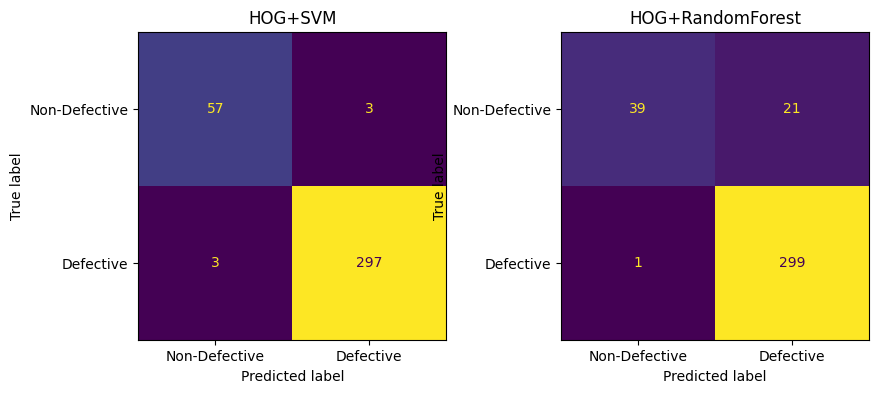

,Acc,Prec,Rec,F1
HOG+SVM,0.9833,0.9900,0.9900,0.9900
HOG+RandomForest,0.9389,0.9344,0.9967,0.9645



##### MULTI-CLASS (6 defects) #####
HOG+SVM {'Acc': 0.9222, 'Prec': 0.9221, 'Rec': 0.9222, 'F1': 0.922}


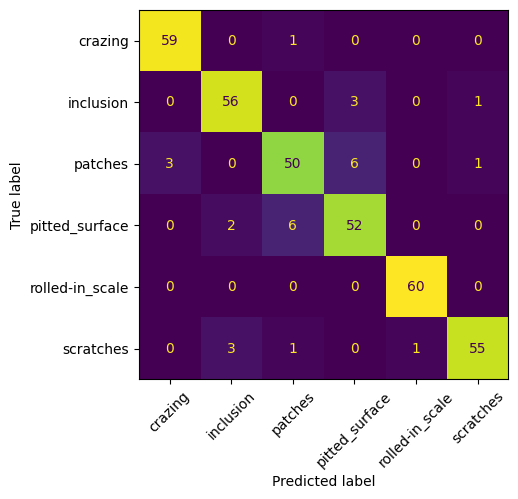

HOG+RF {'Acc': 0.875, 'Prec': 0.8805, 'Rec': 0.875, 'F1': 0.8727}


In [8]:
# CELL 5: Final SVM (RBF) vs Random Forest on best HOG config + confusion matrix + report
F = extract(X_raw, BEST_CELL, BEST_ORI)
svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', probability=True, random_state=42).fit(F[tr], y_bin[tr])
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42).fit(F[tr], y_bin[tr])

res = {}
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (name, m) in zip(ax, [('HOG+SVM', svm), ('HOG+RandomForest', rf)]):
    yp = m.predict(F[te]); res[name] = metrics(y_bin[te], yp)
    ConfusionMatrixDisplay(confusion_matrix(y_bin[te], yp), display_labels=['Non-Defective','Defective']).plot(ax=a, colorbar=False)
    a.set_title(name)
    print("=====", name, "=====\n", classification_report(y_bin[te], yp, target_names=['Non-Defective','Defective']))
plt.show()
display(pd.DataFrame(res).T.round(4))

# Advanced: multi-class (6 defect types)
print("\n##### MULTI-CLASS (6 defects) #####")
for name, m in [('HOG+SVM', SVC(kernel='rbf', C=10, gamma='scale')), ('HOG+RF', RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))]:
    m.fit(F[tr], y_multi[tr]); yp = m.predict(F[te])
    print(name, {k: round(v, 4) for k, v in metrics(y_multi[te], yp, 'macro').items()})
    if name == 'HOG+SVM':
        ConfusionMatrixDisplay(confusion_matrix(y_multi[te], yp), display_labels=CLASSES).plot(xticks_rotation=45, colorbar=False); plt.show()

In [9]:
# CELL 6: Robustness (brightness, noise, rotation, blur)
rng = np.random.default_rng(0)
def bright(i, a): return np.clip(i.astype(np.float32) * a, 0, 255).astype(np.uint8)
def noise(i, s): return np.clip(i + rng.normal(0, s, i.shape), 0, 255).astype(np.uint8)
def rotate(i, d):
    M = cv2.getRotationMatrix2D((IMG_SIZE/2, IMG_SIZE/2), d, 1)
    return cv2.warpAffine(i, M, (IMG_SIZE, IMG_SIZE), borderMode=cv2.BORDER_REFLECT)
def blur(i, k): return cv2.GaussianBlur(i, (k, k), 0)

tests = {'Original': lambda i: i,
         'Brightness x0.6': lambda i: bright(i, .6), 'Brightness x1.4': lambda i: bright(i, 1.4),
         'Noise s=15': lambda i: noise(i, 15), 'Noise s=30': lambda i: noise(i, 30),
         'Rotation 10deg': lambda i: rotate(i, 10), 'Rotation 20deg': lambda i: rotate(i, 20),
         'Blur k=5': lambda i: blur(i, 5), 'Blur k=9': lambda i: blur(i, 9)}
rows = []
for cond, fn in tests.items():
    Ft = extract(np.array([fn(i) for i in X_raw[te]]), BEST_CELL, BEST_ORI)
    for name, m in [('SVM', svm), ('RandomForest', rf)]:
        r = metrics(y_bin[te], m.predict(Ft)); rows.append(dict(Condition=cond, Model=name, Acc=r['Acc'], F1=r['F1']))
rob = pd.DataFrame(rows)
base = rob[rob.Condition == 'Original'].set_index('Model')
rob['dAcc'] = rob.apply(lambda r: r.Acc - base.loc[r.Model, 'Acc'], axis=1)
rob['dF1'] = rob.apply(lambda r: r.F1 - base.loc[r.Model, 'F1'], axis=1)
display(rob.round(4))

,Condition,Model,Acc,F1,dAcc,dF1
0,Original,SVM,0.9833,0.9900,0.0000,0.0000
1,Original,RandomForest,0.9389,0.9645,0.0000,0.0000
2,Brightness x0.6,SVM,0.9694,0.9819,-0.0139,-0.0081
3,Brightness x0.6,RandomForest,0.9056,0.9464,-0.0333,-0.0181
4,Brightness x1.4,SVM,0.9417,0.9660,-0.0417,-0.0240
5,Brightness x1.4,RandomForest,0.9111,0.9494,-0.0278,-0.0151
6,Noise s=15,SVM,0.4833,0.5507,-0.5000,-0.4393
7,Noise s=15,RandomForest,0.5833,0.6739,-0.3556,-0.2906
8,Noise s=30,SVM,0.2222,0.1250,-0.7611,-0.8650
9,Noise s=30,RandomForest,0.3278,0.3240,-0.6111,-0.6405


Actual: patches
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 100.0%
Action: REJECT PRODUCT


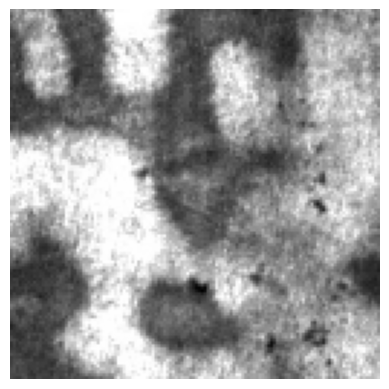

------------------------------
Actual: inclusion
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 100.0%
Action: REJECT PRODUCT


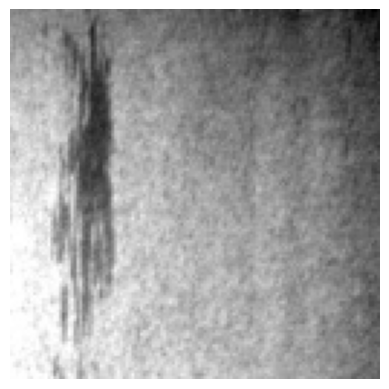

------------------------------
Actual: crazing
PRODUCT INSPECTION RESULT
Prediction: NON-DEFECTIVE
Confidence: 91.0%
Action: ACCEPT PRODUCT


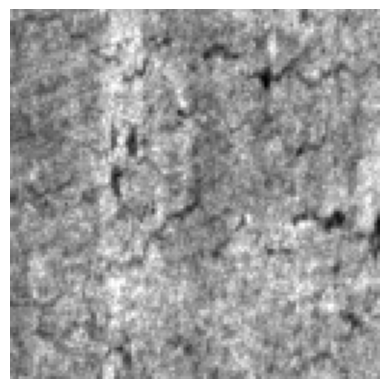

------------------------------


In [10]:
# CELL 7: Industrial Quality-Control decision module
def inspect_product(img_gray, show=True):
    img = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
    f = hog_one(img, BEST_CELL, BEST_ORI).reshape(1, -1)
    p = svm.predict_proba(f)[0]
    pred = int(np.argmax(p)); conf = p[pred] * 100
    print("PRODUCT INSPECTION RESULT")
    print("Prediction:", "DEFECTIVE" if pred == 1 else "NON-DEFECTIVE")
    print(f"Confidence: {conf:.1f}%")
    print("Action:", "REJECT PRODUCT" if pred == 1 else "ACCEPT PRODUCT")
    if show: plt.imshow(img, cmap='gray'); plt.axis('off'); plt.show()

# Test set ki 3 random images par demo
for i in np.random.default_rng(1).choice(te, 3, replace=False):
    print("Actual:", labels[i]); inspect_product(X_raw[i]); print("-" * 30)

# Apni image ke liye: inspect_product(cv2.imread("/content/img.jpg", 0))